# Simple Simulation (10 Jobs)

This notebook runs a minimal simulation of 10 jobs scheduled by a specified trained model.

- Set EXPERIMENT, WORKLOAD, and optional EPOCH
- Loads model weights (final or a specific checkpoint)
- Initializes the HPC environment
- Overrides the episode to 10 jobs
- Steps through scheduling with the model and reports a concise summary



In [1]:
# Configuration
# If your checkpoint lives under a specific workload folder, set EXPERIMENT_PATH
# (e.g., "lublin_256_uni/MARL_carbon_co2direct"). This avoids coupling to the
# SWF file chosen for testing (e.g., frontloaded sanity datasets).

EXPERIMENT_PATH = "lublin_256_carbon_all1/MARL_carbon_Test3"  # e.g., "lublin_256_uni/MARL_carbon_min_only" overrides EXPERIMENT

# You can point WORKLOAD to any SWF (sanity/frontloaded) without affecting where
# the checkpoint is loaded from when EXPERIMENT_PATH is set.
WORKLOAD = "./data/lublin_256_carbon_all1_frontloaded.swf"

BACKFILL = 0   # 0=FCFS, 1=backfill enabled
SEED = 42
DEBUG = False
JOBS_PER_EPISODE = 5  
delayMaxJobNum = 5

action2_num= 7 + delayMaxJobNum + 1


In [2]:
# Imports
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from compare import RL_MultiAction  
from HPCSimPickJobs import *
from util import *
# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
def run_scheduling_loop(env, model, action2_num, delayMaxJobNum, MAX_QUEUE_SIZE):
    # Run scheduling loop
    o = env.build_observation()

    running_num = 0
    step_count = 0

    total_reward = 0.0
    green_reward = 0.0

    scheduled_jobs = []

    while True:
        step_count += 1
        
        # Build action1 mask from env.pairs (like validate.py)
        mask1 = []
        for i in range(MAX_QUEUE_SIZE):
            if i < len(env.pairs) and env.pairs[i][0] is not None:
                mask1.append(0)
            else:
                mask1.append(1)
        
        # Termination when episode jobs processed
        if (env.next_arriving_job_idx >= env.last_job_in_batch and 
            len(env.job_queue) == 0 and len(env.running_jobs) == 0):
            break
        
        # If no jobs to process, try to fast-forward
        if mask1.count(0) == 0 and len(env.job_queue) == 0:
            if hasattr(env, 'fast_forward_to_next_event') and env.fast_forward_to_next_event():
                o = env.build_observation()
                continue
            else:
                break
        
        # Action2 mask
        mask2 = np.zeros(action2_num, dtype=int)
        if running_num < delayMaxJobNum:
            mask2[running_num + 1:delayMaxJobNum + 1] = 1
        
        # Get actions
        a1, a2 = model.eval_action(o, mask1, mask2)
        
        # Capture scheduled job before step
        selected_job = env.job_queue[a1] if a1 < len(env.job_queue) else None
        
        # Step
        o, r, d, r2, sjf_t, f1_t, running_num, greenRwd = env.step(a1, a2)
        total_reward += r
        green_reward += greenRwd

        if step_count < 5:
            print(len(o))
            # print(o[MAX_QUEUE_SIZE*JOB_FEATURES+run_win])
                
        # Track scheduled job
        if selected_job is not None and hasattr(selected_job, 'scheduled_time') and selected_job.scheduled_time != -1:
            scheduled_jobs.append({
                'job_id': getattr(selected_job, 'job_id', None),
                'submit_time': selected_job.submit_time,
                'scheduled_time': selected_job.scheduled_time,
                'request_time': selected_job.request_time,
                'processors': selected_job.request_number_of_processors,
                'carbon_consideration': getattr(selected_job, 'carbon_consideration', -1),
                'power': getattr(selected_job, 'power', 0)
            })
        
        if d:
            break
        # Additional end check when batch jobs submitted
        if env.next_arriving_job_idx >= env.last_job_in_batch and len(env.job_queue) == 0:
            break

    print(f"Steps: {step_count}, total_reward: {total_reward:.4f}, green_reward: {green_reward:.4f}")
    return scheduled_jobs, total_reward, green_reward


In [4]:
def analyze_results(scheduled_jobs, total_reward, green_reward, model_name):

    jobs_df = pd.DataFrame(scheduled_jobs)

    if not jobs_df.empty:
        jobs_df['wait_time'] = jobs_df['scheduled_time'] - jobs_df['submit_time']
       # Visualization: Allocated processors vs carbon intensity over time

    if not jobs_df.empty:
        # Choose time bin size (seconds)
        BIN_SECONDS = 3600  # 1 hour bins; try 900 for 15 minutes

        # Determine plotting window from scheduled jobs
        valid = jobs_df.dropna(subset=['scheduled_time'])
        if not valid.empty:
            start_t = valid['scheduled_time'].min()
            end_t = (valid['scheduled_time'] + valid['request_time']).max()

            # Build bins and accumulator for processors
            time_bins = np.arange(start_t, end_t + BIN_SECONDS, BIN_SECONDS, dtype=int)
            if len(time_bins) < 2:
                time_bins = np.array([start_t, start_t + BIN_SECONDS], dtype=int)
            proc_alloc = np.zeros(len(time_bins) - 1, dtype=float)

            # Accumulate processors per bin for running intervals
            for _, row in valid.iterrows():
                st = int(row['scheduled_time'])
                et = int(row['scheduled_time'] + row['request_time'])
                procs = float(row['processors'])
                # Overlap mask: bin [t_i, t_{i+1}) intersects [st, et)
                left = time_bins[:-1]
                right = time_bins[1:]
                mask = (left < et) & (right > st)
                proc_alloc[mask] += procs

            # Carbon intensity per bin (use intensity at bin start)
            
            carbon_vals = []
            for t in time_bins[:-1]:
                carbon_intensity_at_t = env.cluster.carbonIntensity.getCurrentIntensity(t)
                carbon_vals.append(carbon_intensity_at_t)
            carbon_vals = np.array(carbon_vals, dtype=float)

            # X coordinates in hours relative to start
            rel_hours = (time_bins[:-1] - start_t) / 3600.0

            # Plot
            fig, ax1 = plt.subplots(figsize=(10, 4))
            ax1.bar(rel_hours, proc_alloc, width=(BIN_SECONDS/3600.0), align='edge',
                    color='#1f77b4', alpha=0.6, edgecolor='#1f77b4', label='Allocated processors')
            ax1.set_xlabel('Time (hours from episode start)')
            ax1.set_ylabel('Allocated processors')

            ax2 = ax1.twinx()
            ax2.plot(rel_hours, carbon_vals, color='green', linewidth=2.0, label='Carbon intensity (gCO2/kWh)')
            ax2.set_ylabel('Carbon intensity (gCO2/kWh)')

            # Legends
            h1, l1 = ax1.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax1.legend(h1 + h2, l1 + l2, loc='upper right')
            plt.title(f'Allocated processors vs Carbon intensity for {model_name}')
            plt.tight_layout()
            plt.show()
        else:
            print('No scheduled jobs to visualize yet.')
    else:
        print('No jobs were scheduled.')



In [5]:

# Load in epoch 35 vs 5
env = initialize_environment(WORKLOAD, BACKFILL, DEBUG, SEED, JOBS_PER_EPISODE)
print("Envoriment Loaded")
model_epoch_5 = initialize_model(EXPERIMENT_PATH, WORKLOAD, 5)
model_epoch_35 = initialize_model(EXPERIMENT_PATH, WORKLOAD, 10)

models = [
    {'name': 'epoch_5', 'model': model_epoch_5},
    {'name': 'epoch_35', 'model': model_epoch_35}
]

for entry in models:
    env.reset(episode_start_hour_offset=0)
    scheduled_jobs, total_reward, green_reward = run_scheduling_loop(
        env, entry['model'], action2_num, delayMaxJobNum, MAX_QUEUE_SIZE
    )
    analyze_results(scheduled_jobs, total_reward, green_reward, entry['name'])



Using workload: ./data/lublin_256_carbon_all1_frontloaded.swf
Initialize Simple HPC Env
loading workloads from dataset: ./data/lublin_256_carbon_all1_frontloaded.swf
Using constant power: 500.0 watts per processor
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 124707
Envoriment Loaded
Device:  cpu


TypeError: PPO.__init__() got an unexpected keyword argument 'inputNum_size'

## Convergence

In [6]:
results_csv_path = EXPERIMENT_PATH + "/training_results.csv"
df = pd.read_csv(results_csv_path)

df.head()


,epoch,episode_return_mean,episode_return_median,avg_epoch_reward,avg_green_reward,avg_wait_reward,carbon_cost_mean,latency_mean,policy_loss_clipped,policy_loss_unclipped,entropy,approx_kl,clip_fraction,value_loss,explained_variance,adv_mean,adv_std
0,1,-0.083315,-0.083315,-0.083315,-0.083315,0.0,-0.083315,0.0,-0.035554,-0.002925,3.262876,0.005871,0.052239,0.268396,4.892796e-07,-0.015590,0.135817
1,2,-0.013368,-0.013368,-0.013368,-0.013368,0.0,-0.013368,0.0,-0.034062,-0.001638,3.242418,0.004489,0.024299,0.007265,1.774542e-06,0.018127,0.037386
2,3,-0.009685,-0.009685,-0.009685,-0.009685,0.0,-0.009685,0.0,-0.036534,-0.004016,3.251755,0.006481,0.048467,0.004985,2.468899e-06,0.000908,0.018215
3,4,-0.004765,-0.004765,-0.004765,-0.004765,0.0,-0.004765,0.0,-0.036452,-0.004074,3.237776,0.008627,0.076829,0.000823,1.318883e-05,0.001373,0.007732
4,5,-0.001857,-0.001857,-0.001857,-0.001857,0.0,-0.001857,0.0,-0.036740,-0.004256,3.248400,0.006107,0.062141,0.000219,5.470868e-05,0.000778,0.004023


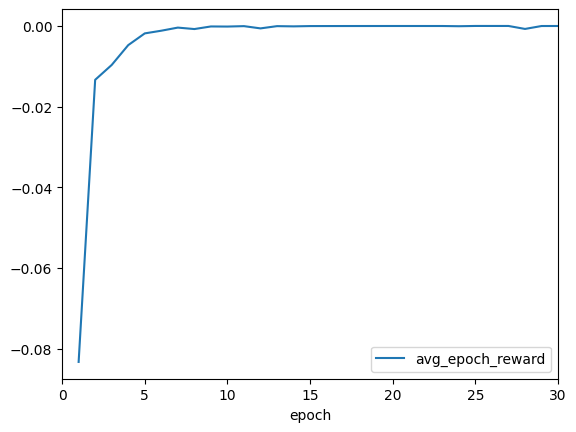

In [7]:
fig, ax = plt.subplots()
df.plot(x='epoch', y=['avg_epoch_reward',], ax=ax)
ax.set_xlim((0,30))
plt.show()